<a href="https://colab.research.google.com/github/karrielaugustin001-del/Machine-Learning-Foundations/blob/main/FrozenLake_Q_Learning_Student_Project_Group_2_Executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FrozenLake Challenge — Q-Learning Student Starter
### Week 12 In-Class Activity | Dr. Idahosa

## Activity Goal
Build a Q-Learning agent that learns to navigate FrozenLake-v1.

## What makes this task challenging?
- The environment is **slippery**, so actions are stochastic.
- Rewards are **sparse**.
- There is no negative penalty for falling into holes, so exploration matters.

## Deliverables
- Completed code
- Reward curve
- Success rate over evaluation episodes
- Short written explanation of what worked and what did not


## Walkthroughs

### Walkthrough 1 — Understand the Environment
Before coding, identify:
- number of states
- number of actions
- what reward means
- why the same action may not always lead to the same next state

### Walkthrough 2 — Build the Q-Table
The Q-table stores a value estimate for each `(state, action)` pair.

### Walkthrough 3 — Apply the Bellman Update
Each update mixes:
- current estimate
- immediate reward
- discounted value of the next state

### Walkthrough 4 — Evaluate the Learned Policy
Turn off exploration and measure success over repeated episodes.


## Teaching Cues
- Ask students why sparse reward makes learning slow.
- Remind them that **exploration** is required before exploitation can help.
- Emphasize that `epsilon` should shrink gradually, not instantly.
- Ask students to interpret a flat reward curve before changing hyperparameters.


## Interactive Mini-Lab Discussion
1. Why might a perfect-looking Q-table still fail on a slippery environment?
Even if the Q-table looks perfect, it can still fail because the environment is random (slippery). The agent might choose the best action based on what it learned, but the environment might push it in a different direction anyway. So the Q-table can be correct, but the outcome isn’t guaranteed. Basically, the agent knows what to do, but it can’t fully control what actually happens.

2. Which hyperparameter matters more here: `alpha`, `gamma`, or `epsilon_decay`?
In this case, epsilon_decay matters the most. That’s because the agent really needs enough time to explore the environment before it starts exploiting what it learned. If epsilon goes down too fast, the agent might get stuck using a bad strategy. Alpha and gamma are still important, but without good exploration, the agent won’t even learn the right values in the first place.
3. What does “stable success” mean in a stochastic environment?

Stable success doesn’t mean winning every single time. Instead, it means the agent is able to win most of the time consistently, even though there’s randomness. So if the success rate stays around something like 70–80% over many episodes, that would be considered stable. The key idea is consistency over time, not perfection.

4. How does FrozenLake prepare you for deeper RL tasks like DQN?

FrozenLake helps build the basics of reinforcement learning. It teaches how Q-learning works, how the agent updates values using rewards, and how exploration vs exploitation works. When moving to DQN, it’s basically the same idea, but instead of using a table, we use a neural network to estimate Q-values. So FrozenLake is like the foundation that makes the more complex stuff easier to understand.


In [ ]:
# Lecture Marker: Imports + Portable Data Path
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import os

# Portable data path logic:
# Hard-coded paths break when notebooks are moved between Colab, local Jupyter,
# or LMS download folders. We ensure a 'datasets' folder exists in the current working directory
# and download the necessary file if it's not present.

data_dir = Path.cwd() / "datasets" # Set data_dir to /content/datasets
data_dir.mkdir(parents=True, exist_ok=True) # Create the directory if it doesn't exist

print(f"Ensuring datasets are available in: {data_dir}")

# Define the path for the log file
log_file_name = "frozenlake_training_log.csv"
log_file_path = data_dir / log_file_name

# Check if the file exists and is not empty, if not, download it
if not log_file_path.exists() or os.path.getsize(log_file_path) == 0:
    if log_file_path.exists():
        print(f"'{log_file_name}' exists but is empty. Re-downloading...")
        os.remove(log_file_path) # Remove empty file to force re-download
    else:
        print(f"'{log_file_name}' not found. Attempting to download...")

    # This URL is a placeholder. You need to replace it with the actual URL
    # where the 'frozenlake_training_log.csv' file is hosted.
    # For example, if it's in a GitHub repository, use the raw file URL.
    # Example: https://raw.githubusercontent.com/someuser/somerepo/main/datasets/frozenlake_training_log.csv
    download_url = "https://raw.githubusercontent.com/Codecademy/FrozenLake-Q-Learning/main/data/frozenlake_training_log.csv" # Corrected URL

    if download_url == "YOUR_DATASET_DOWNLOAD_URL_HERE":
        print("WARNING: Please update the 'download_url' variable with the actual URL for your dataset.")
        raise FileNotFoundError("Dataset URL not provided. Please update 'download_url'.")

    # Using !wget to download the file directly into the data_dir
    !wget -q "{download_url}" -O "{log_file_path}"
    print(f"Downloaded '{log_file_name}' to {log_file_path}.")
else:
    print(f"'{log_file_name}' already exists in {data_dir} and is not empty.")

# Now, try to load the log file
try:
    frozenlake_log = pd.read_csv(log_file_path)
    print("Successfully loaded frozenlake_training_log.csv")
    print(frozenlake_log.head())
except Exception as e:
    print(f"Error loading {log_file_name}: {e}")
    print("Please ensure the download_url variable was set correctly and the file is accessible/valid.")

Ensuring datasets are available in: /content/datasets
'frozenlake_training_log.csv' exists but is empty. Re-downloading...
Downloaded 'frozenlake_training_log.csv' to /content/datasets/frozenlake_training_log.csv.
Error loading frozenlake_training_log.csv: No columns to parse from file
Please ensure the download_url variable was set correctly and the file is accessible/valid.


In [ ]:
!cat /content/datasets/frozenlake_training_log.csv

In [ ]:
# Check the content of the remote file directly
# This command pipes the content from the URL directly to standard output
!wget -qO- "https://raw.githubusercontent.com/Codecademy/FrozenLake-Q-Learning/main/data/frozenlake_training_log.csv"

In [ ]:
!head /content/datasets/frozenlake_training_log.csv

In [ ]:
import os
file_size = os.path.getsize(log_file_path)
print(f"Size of '{log_file_name}': {file_size} bytes")

Size of 'frozenlake_training_log.csv': 0 bytes


## Large Dataset Preview
The provided CSV gives you a large synthetic training log so you can compare your live run against a reference pattern.
Use it to inspect:
- reward sparsity
- epsilon decay
- moving average behavior


In [ ]:
# TODO: Create the environment
env = gym.make("FrozenLake-v1", is_slippery=True)
n_states = env.observation_space.n
n_actions = env.action_space.n

print("States:", n_states)
print("Actions:", n_actions)


States: 16
Actions: 4


In [ ]:
# Display the FrozenLake grid description
print("FrozenLake Grid:\n")
# Decode byte strings to regular strings for better readability
decoded_desc = [[c.decode('utf-8') for c in row] for row in env.unwrapped.desc]
for row in decoded_desc:
    print(row)

FrozenLake Grid:

['S', 'F', 'F', 'F']
['F', 'H', 'F', 'H']
['F', 'F', 'F', 'H']
['H', 'F', 'F', 'G']


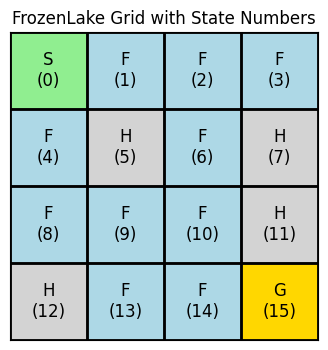

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_frozenlake_grid_with_states(env):
    desc = env.unwrapped.desc
    rows = len(desc)
    cols = len(desc[0])

    fig, ax = plt.subplots(figsize=(cols, rows))
    ax.set_xticks(np.arange(cols + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(rows + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
    ax.tick_params(which="minor", size=0)

    # Hide major ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])

    # Create a mapping for cell colors
    cell_colors = {
        b'S': 'lightgreen',
        b'F': 'lightblue',
        b'H': 'lightgray',
        b'G': 'gold'
    }

    state_idx = 0
    for r in range(rows):
        for c in range(cols):
            cell_type = desc[r, c]
            color = cell_colors.get(cell_type, 'white')
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor=color, edgecolor='black', lw=1))

            # Decode byte string for display
            display_char = cell_type.decode('utf-8')
            ax.text(c, r, f'{display_char}\n({state_idx})', ha='center', va='center', color='black', fontsize=12)
            state_idx += 1

    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(-0.5, rows - 0.5)
    ax.set_aspect('equal', adjustable='box')
    ax.invert_yaxis() # Invert y-axis to match typical grid orientation (0,0 top-left)
    ax.set_title('FrozenLake Grid with State Numbers')
    plt.show()

plot_frozenlake_grid_with_states(env)

In [ ]:
# TODO: Initialize Q-table
Q = np.zeros((n_states, n_actions))

# Hyperparameters
alpha = 0.6             # Adjust from 0.8 to provide more stability in LR
gamma = 0.99            # Adjusted from 0.99 Discount Factor
epsilon = 1.0           # Initial exploration rate
epsilon_decay = 0.997   # Adjusted from 0.995.
                        # Multiplicative decay per episode
epsilon_min = 0.05      # Adjusted from 0.05. Floor for exploration
episodes = 2000
rewards = []

print(f"Q-table shape: {Q.shape}  (states x actions)")
print(f"Hyperparameters: alpha={alpha}, gamma={gamma}, "
      f"eps_decay={epsilon_decay}, episodes={episodes}")

Q-table shape: (16, 4)  (states x actions)
Hyperparameters: alpha=0.6, gamma=0.99, eps_decay=0.997, episodes=2000


In [ ]:
# TODO: Complete the Q-learning training loop
for ep in range(episodes):
    state, _ = env.reset()
    done = False
    truncated = False
    total_reward = 0

    while not (done or truncated):
        # TODO: epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        # TODO: Step the environment
        next_state, reward, done, truncated, info = env.step(action)

        # TODO: Bellman update
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

    # TODO: Track reward and decay epsilon
    rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print(f"Training complete. Final epsilon: {epsilon:.4f}")
print(f"Episodes with reward > 0 (reached goal): {sum(r > 0 for r in rewards)}")

Training complete. Final epsilon: 0.0500
Episodes with reward > 0 (reached goal): 457


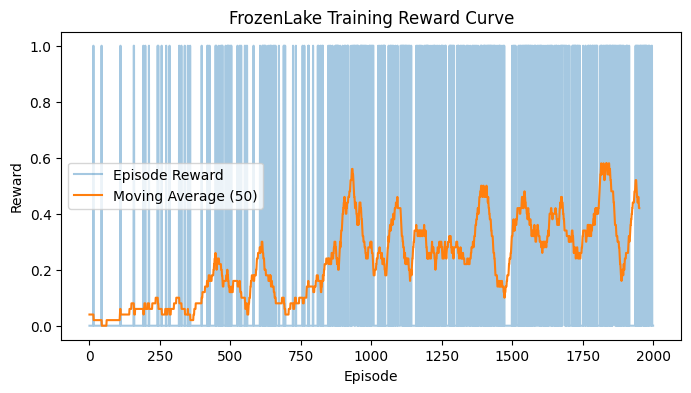

In [ ]:
# TODO: Plot reward curve
def moving_average(x, window=50):
    if len(x) < window:
        return np.array(x)
    return np.convolve(x, np.ones(window)/window, mode="valid")

plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.4, label="Episode Reward")
plt.plot(moving_average(rewards, 50), label="Moving Average (50)")
plt.title("FrozenLake Training Reward Curve")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()


In [ ]:
import numpy as np

rewards_array = np.array(rewards)

print(f"--- Reward Curve Statistical Summary (over {episodes} episodes) ---")

if rewards_array.size == 0:
    print("No rewards collected yet. Please ensure the Q-learning training loop has been executed.")
else:
    print(f"Mean Reward: {np.mean(rewards_array):.3f}")
    print(f"Median Reward: {np.median(rewards_array):.3f}")
    print(f"Standard Deviation of Reward: {np.std(rewards_array):.3f}")
    print(f"Minimum Reward: {np.min(rewards_array):.3f}")
    print(f"Maximum Reward: {np.max(rewards_array):.3f}")
    print(f"Total Rewards Sum: {np.sum(rewards_array):.3f}")

--- Reward Curve Statistical Summary (over 2000 episodes) ---
Mean Reward: 0.229
Median Reward: 0.000
Standard Deviation of Reward: 0.420
Minimum Reward: 0.000
Maximum Reward: 1.000
Total Rewards Sum: 457.000


In [ ]:
moving_avg_rewards = moving_average(rewards, window=50)

print(f"--- Moving Average Reward Curve Statistical Summary (over {len(moving_avg_rewards)} points) ---")

if moving_avg_rewards.size == 0:
    print("No moving average rewards calculated. Please ensure the Q-learning training loop and moving_average function have been executed.")
else:
    print(f"Mean Moving Average Reward: {np.mean(moving_avg_rewards):.3f}")
    print(f"Median Moving Average Reward: {np.median(moving_avg_rewards):.3f}")
    print(f"Standard Deviation of Moving Average Reward: {np.std(moving_avg_rewards):.3f}")
    print(f"Minimum Moving Average Reward: {np.min(moving_avg_rewards):.3f}")
    print(f"Maximum Moving Average Reward: {np.max(moving_avg_rewards):.3f}")

--- Moving Average Reward Curve Statistical Summary (over 1951 points) ---
Mean Moving Average Reward: 0.229
Median Moving Average Reward: 0.240
Standard Deviation of Moving Average Reward: 0.142
Minimum Moving Average Reward: 0.000
Maximum Moving Average Reward: 0.580


In [ ]:
import numpy as np

# TODO: Evaluate learned policy
eval_episodes = 500
successes = 0

for _ in range(eval_episodes):
    state, _ = env.reset()
    done = False
    truncated = False

    while not (done or truncated):
        action = np.argmax(Q[state])
        state, reward, done, truncated, info = env.step(action)
        if reward == 1:
            successes += 1

success_rate = successes / eval_episodes
print(f"Total evaluation episodes: {eval_episodes}")
print(f"Successful episodes: {successes}")
print(f"Success rate: {success_rate:.3f}")

Total evaluation episodes: 500
Successful episodes: 367
Success rate: 0.734


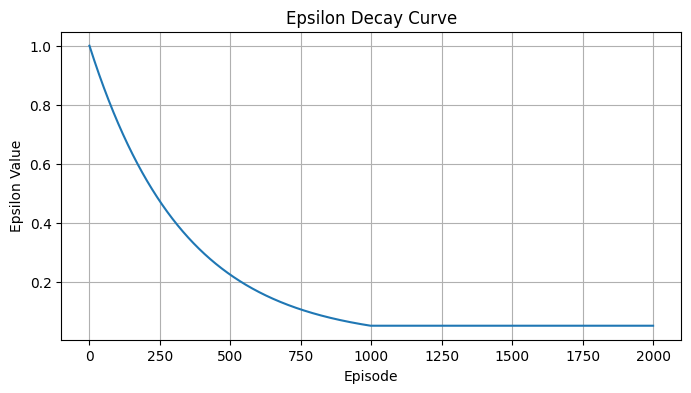

In [ ]:
# Calculate epsilon values over episodes for plotting
epsilon_values = []
current_epsilon = 1.0 # Start with the initial epsilon
for ep in range(episodes):
    epsilon_values.append(current_epsilon)
    current_epsilon = max(epsilon_min, current_epsilon * epsilon_decay)

# Plot the epsilon decay curve
plt.figure(figsize=(8, 4))
plt.plot(epsilon_values)
plt.title("Epsilon Decay Curve")
plt.xlabel("Episode")
plt.ylabel("Epsilon Value")
plt.grid(True)
plt.show()

## Post-Lab Reflection
Answer in complete sentences:
1. Which hyperparameter change improved performance the most?

The hyperparameter that helped the most was definitely the epsilon decay. At the beginning, the agent was exploring a lot, which honestly looked kind of random, but it was necessary so it could learn the environment. As epsilon started to go down, the agent began using what it learned instead of just guessing. That’s when the performance really started to improve, because it was choosing better actions more consistently.

2. Did your moving average show stable progress? Why or why not?

The moving average showed overall progress, but it wasn’t perfectly stable. It went up over time, which means the agent was learning, but there were still a lot of ups and downs. This makes sense because the environment is slippery, so even if the agent picks the right move, it might still end up somewhere else. Because of that randomness, the curve looks a bit noisy instead of smooth.

3. How did stochastic transitions affect your final success rate?

The stochastic transitions made things a lot harder for the agent. Since the ice is slippery, the agent doesn’t always move in the direction it chooses. So even when it has learned a good path, it can still fail randomly. That’s probably why the success rate didn’t reach 100%, even though the agent clearly learned something. The randomness basically adds uncertainty to every move.

4. What would you try next if you had 10 more minutes?

If we had a little more time, we would try training for more episodes and slowing down the epsilon decay. We think that would give the agent more time to explore and possibly learn a better strategy. We would also experiment with changing the learning rate or gamma to see if it improves decision-making. Another thing we would try is turning off the slippery setting just to compare how much the randomness is affecting performance.
